# Predicting Logistics Delays with Smart Supply Chain Data

This project uses a smart logistics dataset with IoT-enriched data to understand why delays happen in the supply chain. 

My goal is to show how advanced analytics can identify key risk patterns and help logistics companies take proactive actions to reduce delays.

This project is done as an additional application material for Data Analytics Intern at FWF application


In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Load the Dataset

In [3]:
df = pd.read_csv("smart_logistics_dataset.csv")
df.head()

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,None,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,None,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,None,71.6,270,1


#  ETL: Clean and Prepare the Data

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert Timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['month'] = df['timestamp'].dt.month_name()


In [5]:
#handle missing values
df.isnull().sum()
df = df.dropna(subset=["logistics_delay"])
df["logistics_delay_reason"] = df["logistics_delay_reason"].fillna("Unspecified")
df["traffic_status"] = df["traffic_status"].fillna("Unknown")

# Data Exploration & Visualization

### Lets see why we have delays
#### a. Delay by Traffic Status

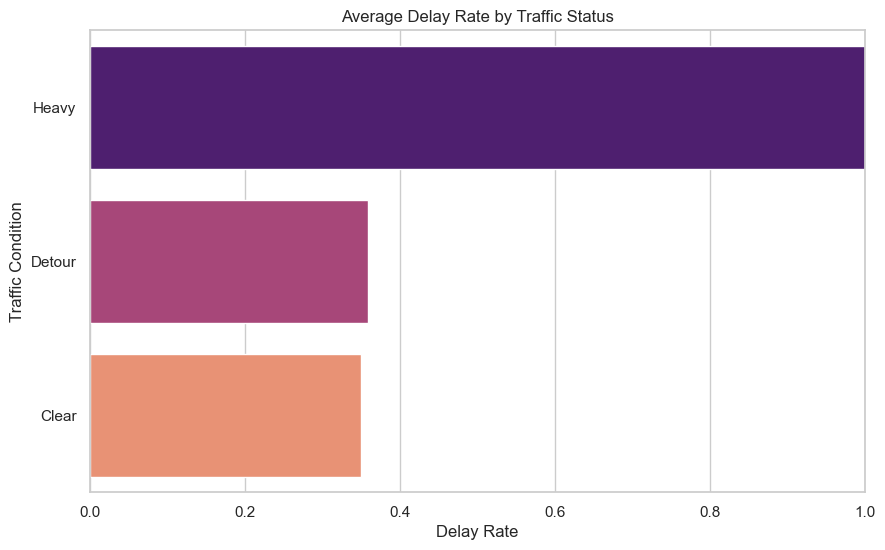

In [6]:
sns.set(style="whitegrid")
delay_by_traffic = df.groupby("traffic_status")["logistics_delay"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=delay_by_traffic.values, y=delay_by_traffic.index, palette="magma")
plt.title("Average Delay Rate by Traffic Status")
plt.xlabel("Delay Rate")
plt.ylabel("Traffic Condition")
plt.xlim(0, 1)
plt.show()


It is reasonable to see that the highest average delay rate occur when the traffic is heavy

#### b. Delay Rate by Month

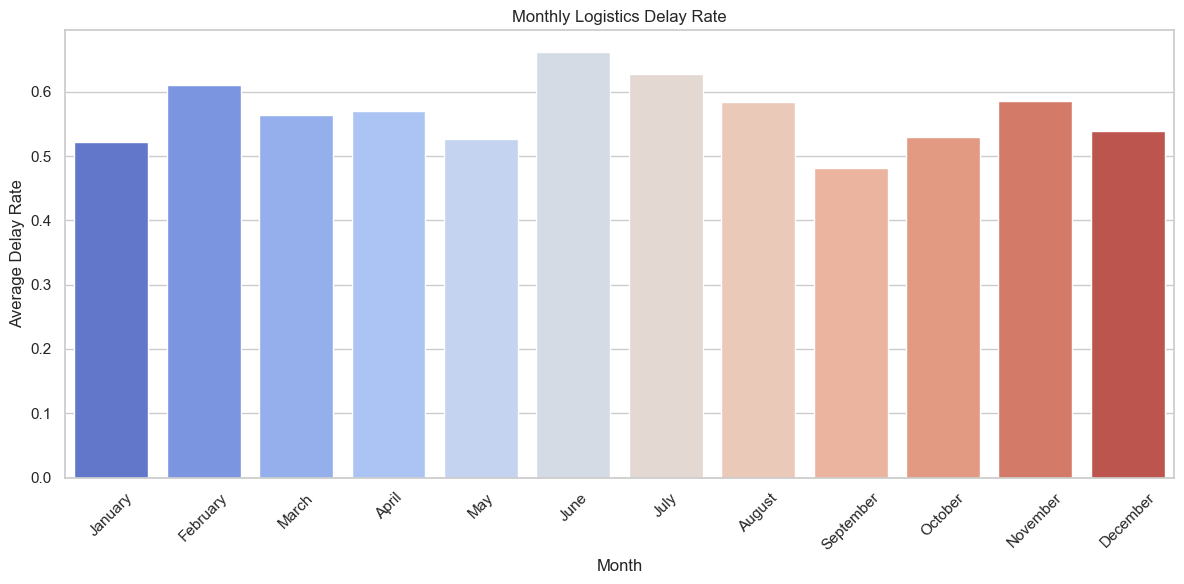

In [7]:
monthly_delay = df.groupby("month")["logistics_delay"].mean().reindex([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
])

plt.figure(figsize=(12,6))
sns.barplot(x=monthly_delay.index, y=monthly_delay.values, palette="coolwarm")
plt.title("Monthly Logistics Delay Rate")
plt.ylabel("Average Delay Rate")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


I see a pattern in the delay seen ove month. The average delay rate increases 3 times a year and june is month where I see the highest average delay.

Let's add visualizations to explore why delays peak in certain months, using environmental and operational features like:

- Average waiting time

- Traffic conditions

- Asset utilization

- Demand forecast

- Temperature / Humidity


#### 1. Monthly Average Waiting Time

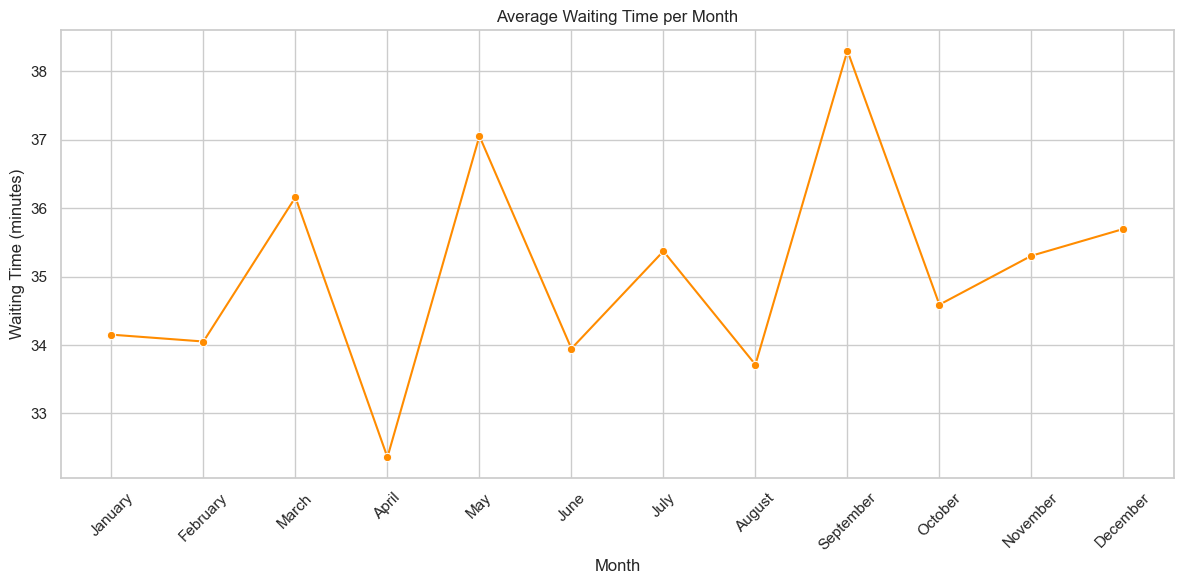

In [8]:
monthly_waiting = df.groupby("month")["waiting_time"].mean().reindex([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
])

plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_waiting.index, y=monthly_waiting.values, marker='o', color='darkorange')
plt.title("Average Waiting Time per Month")
plt.xlabel("Month")
plt.ylabel("Waiting Time (minutes)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


####  2. Monthly Distribution of Traffic Status

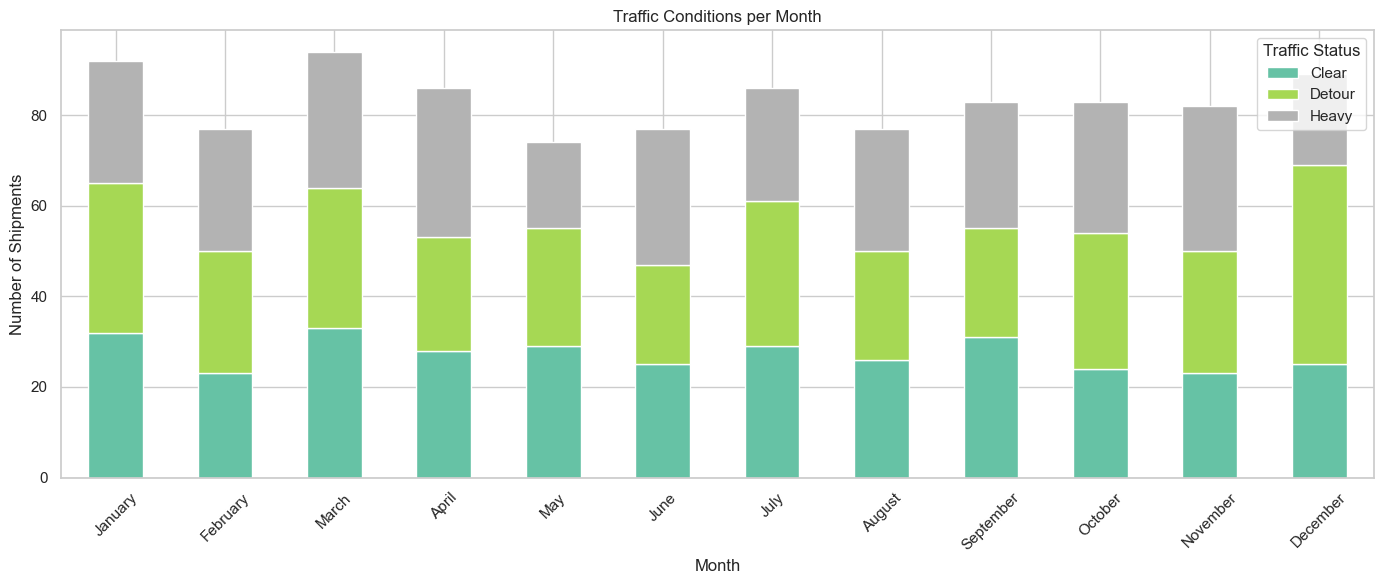

In [9]:
monthly_traffic = df.groupby(["month", "traffic_status"]).size().unstack().fillna(0).reindex([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
])

monthly_traffic.plot(kind="bar", stacked=True, figsize=(14,6), colormap="Set2")
plt.title("Traffic Conditions per Month")
plt.xlabel("Month")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)
plt.legend(title="Traffic Status")
plt.tight_layout()
plt.show()


####  3. Monthly Average Asset Utilization

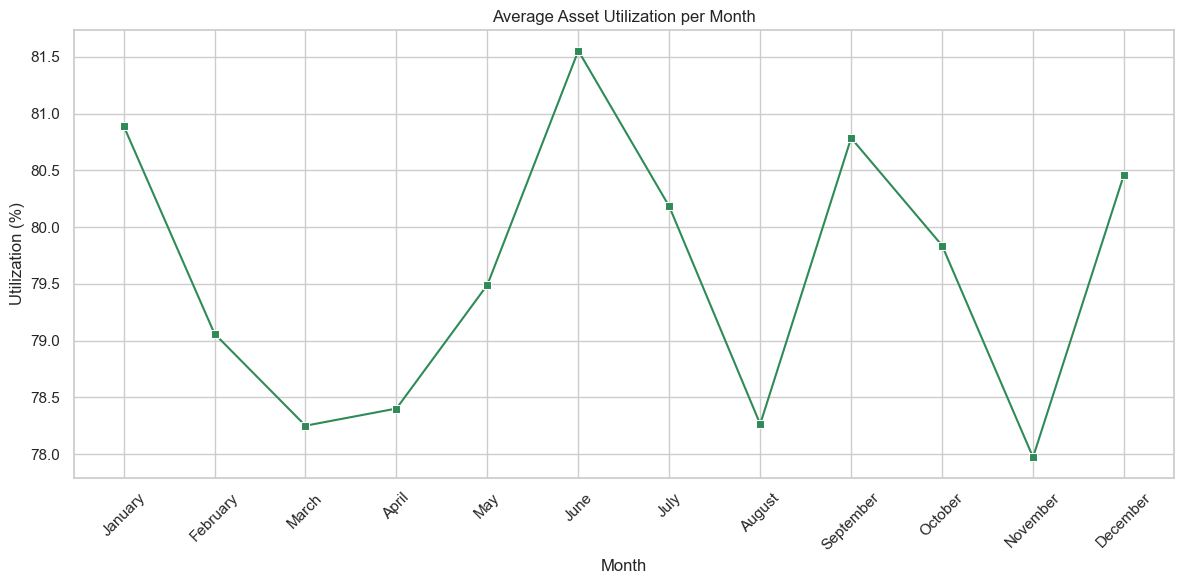

In [10]:
monthly_utilization = df.groupby("month")["asset_utilization"].mean().reindex([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
])

plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_utilization.index, y=monthly_utilization.values, marker='s', color='seagreen')
plt.title("Average Asset Utilization per Month")
plt.xlabel("Month")
plt.ylabel("Utilization (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


#### 4. Monthly Average Demand Forecast

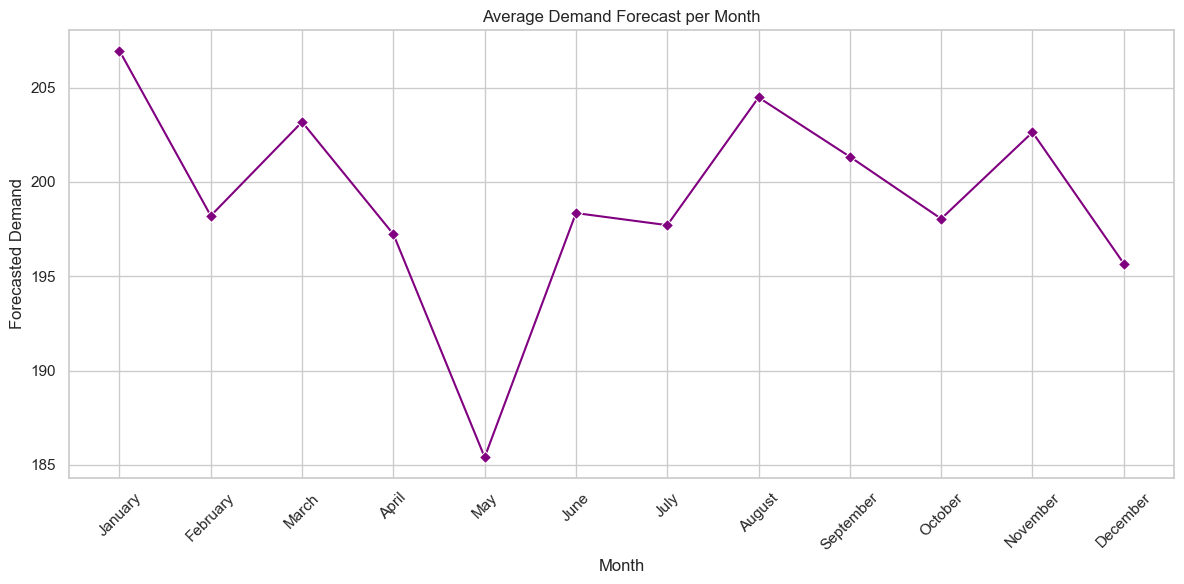

In [11]:
monthly_demand = df.groupby("month")["demand_forecast"].mean().reindex([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
])

plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_demand.index, y=monthly_demand.values, marker='D', color='purple')
plt.title("Average Demand Forecast per Month")
plt.xlabel("Month")
plt.ylabel("Forecasted Demand")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


#### 5. Monthly Temperature and Humidity

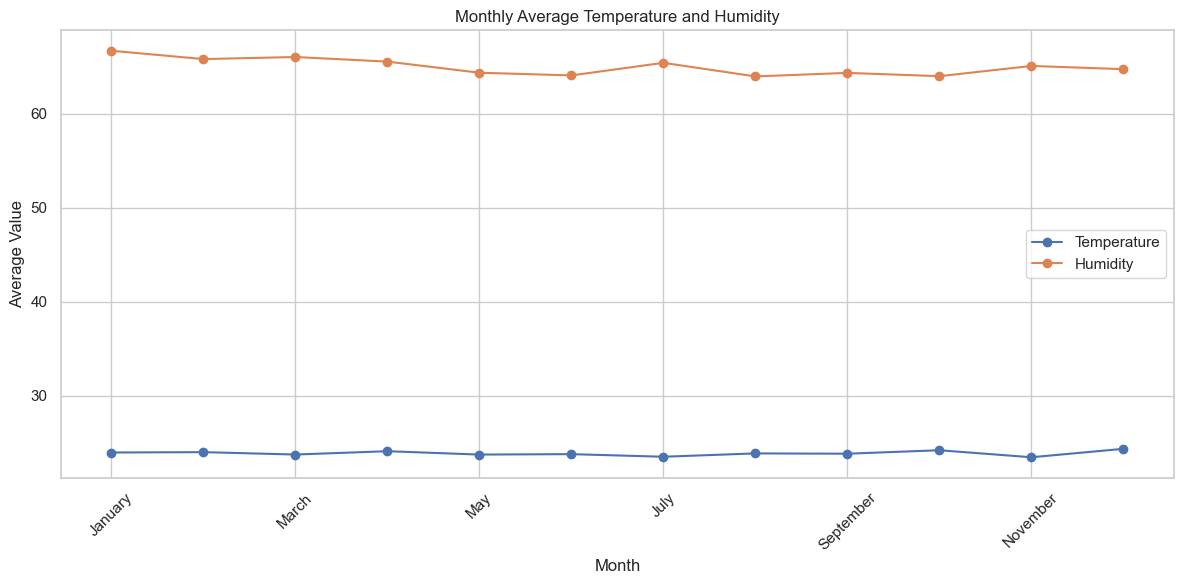

In [12]:
monthly_temp_hum = df.groupby("month")[["temperature", "humidity"]].mean().reindex([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
])

monthly_temp_hum.plot(figsize=(12,6), marker='o')
plt.title("Monthly Average Temperature and Humidity")
plt.xlabel("Month")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(["Temperature", "Humidity"])
plt.tight_layout()
plt.show()


## Why Do Delays Vary by Month?

### 1. Waiting Time Increases in May & September
- Waiting time peaks in **May** and again in **September**.
- Longer wait times lead to slower deliveries and more delays.
- This may be due to seasonal rush or staffing gaps.

> **Insight:** Delays increase when shipments wait too long. Improving processing speed in peak months can help.

---

### 2. More Traffic Issues in September & December
- More shipments in **September and December** face **Heavy** or **Detour** traffic.
- Traffic congestion slows down routes, increasing delays.

> **Insight:** Traffic-aware route planning could reduce delays in busy months.

---

### 3. Asset Utilization Drops in March, August & November
- Trucks and resources were used less in **March**, **August**, and **November**.
- Even with lower usage, delays still happened — possibly due to vacations or poor scheduling.

> **Insight:** Better planning is needed to match truck usage with shipment demand.

---

### 4. Demand Spikes in January, March & August
- Forecasted demand is highest in **January**, **March**, and **August**.
- High demand puts pressure on the system, leading to missed timelines.

> **Insight:** Align staffing and resources with expected demand to reduce overload.

---

### 5. Temperature & Humidity Are Not Major Factors
- These stayed mostly stable all year.
- They don’t seem to be the reason for delays.

> **Insight:** Environmental factors like temperature/humidity are less important than traffic or timing.

---

###  Summary:
Delays mostly happen when:
- Waiting times are long
- Traffic is heavy
- Trucks are underused
- Demand is high but not well-planned



### Predictive Modeling

In [13]:
df["logistics_delay"] = df["logistics_delay"].astype(int)
features = ["temperature", "humidity", "traffic_status", "logistics_delay_reason", "asset_utilization", "waiting_time", "demand_forecast"]
X = df[features]
y = df["logistics_delay"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

encoder = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["traffic_status", "logistics_delay_reason"])
    ],
    remainder="passthrough"
)


In [15]:
model = Pipeline([
    ("encoder", encoder),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.66      0.90      0.76        91
           1       0.88      0.61      0.72       109

    accuracy                           0.74       200
   macro avg       0.77      0.76      0.74       200
weighted avg       0.78      0.74      0.74       200



### Feature Importance

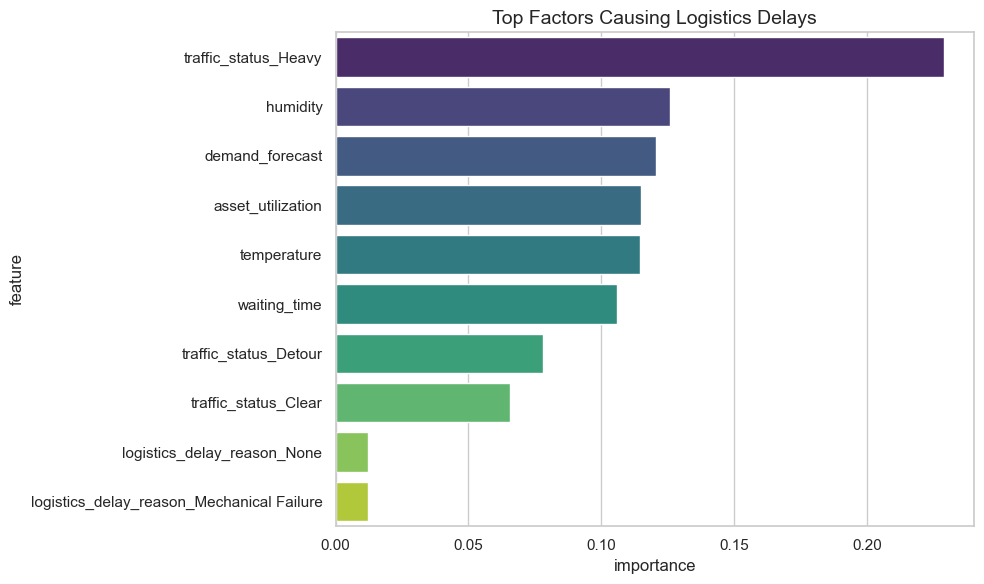

In [19]:
encoded_cats = model.named_steps["encoder"].named_transformers_["cat"].get_feature_names_out(
    ["traffic_status", "logistics_delay_reason"]
)

numeric_features = ["temperature", "humidity", "asset_utilization", "waiting_time", "demand_forecast"]
all_features = list(encoded_cats) + numeric_features

importances = model.named_steps["rf"].feature_importances_



feat_imp = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(10), x="importance", y="feature", palette="viridis")
plt.title("Top Factors Causing Logistics Delays", fontsize=14)
plt.tight_layout()
plt.show()



## Final Conclusion

This analysis revealed key operational and environmental drivers of logistics delays:

- **Traffic status**, particularly `Heavy`, was the strongest contributor to delays, followed by **humidity**, **demand**, and **asset utilization**.
- The Random Forest model achieved **74% overall accuracy**, with **strong precision (0.88)** for identifying delays — making it useful for proactive risk detection.

**Operational Takeaway:** Logistic companies can use models like this to prioritize shipments facing high-risk conditions (e.g., heavy traffic, poor utilization) and adjust routes or schedules accordingly.
